In [1]:
%pip install -q --upgrade datasets pandas beautifulsoup4 lxml playwright trafilatura tqdm
!playwright install chromium
# Trên Linux/Colab, nếu thiếu system libraries, chạy thay dòng trên bằng:
# !playwright install --with-deps chromium


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 1.2.1 requires huggingface-hub<2.0.0,>=0.33.4, but you have huggingface-hub 2.1.1 which is incompatible.
tokenizers 0.22.2 requires huggingface-hub<2.0,>=0.16.4, but you have huggingface-hub 2.1.1 which is incompatible.
transformers 5.5.4 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 2.1.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset
ds = load_dataset("AIGuruTinix/ViBioMIR", 'corpus')


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
urls_full = ds["train"]["url"]
len(urls_full)


4394718

# Analyze the distribution of domains in the dataset

Total URLs: 4,394,718
Total unique domains: 97


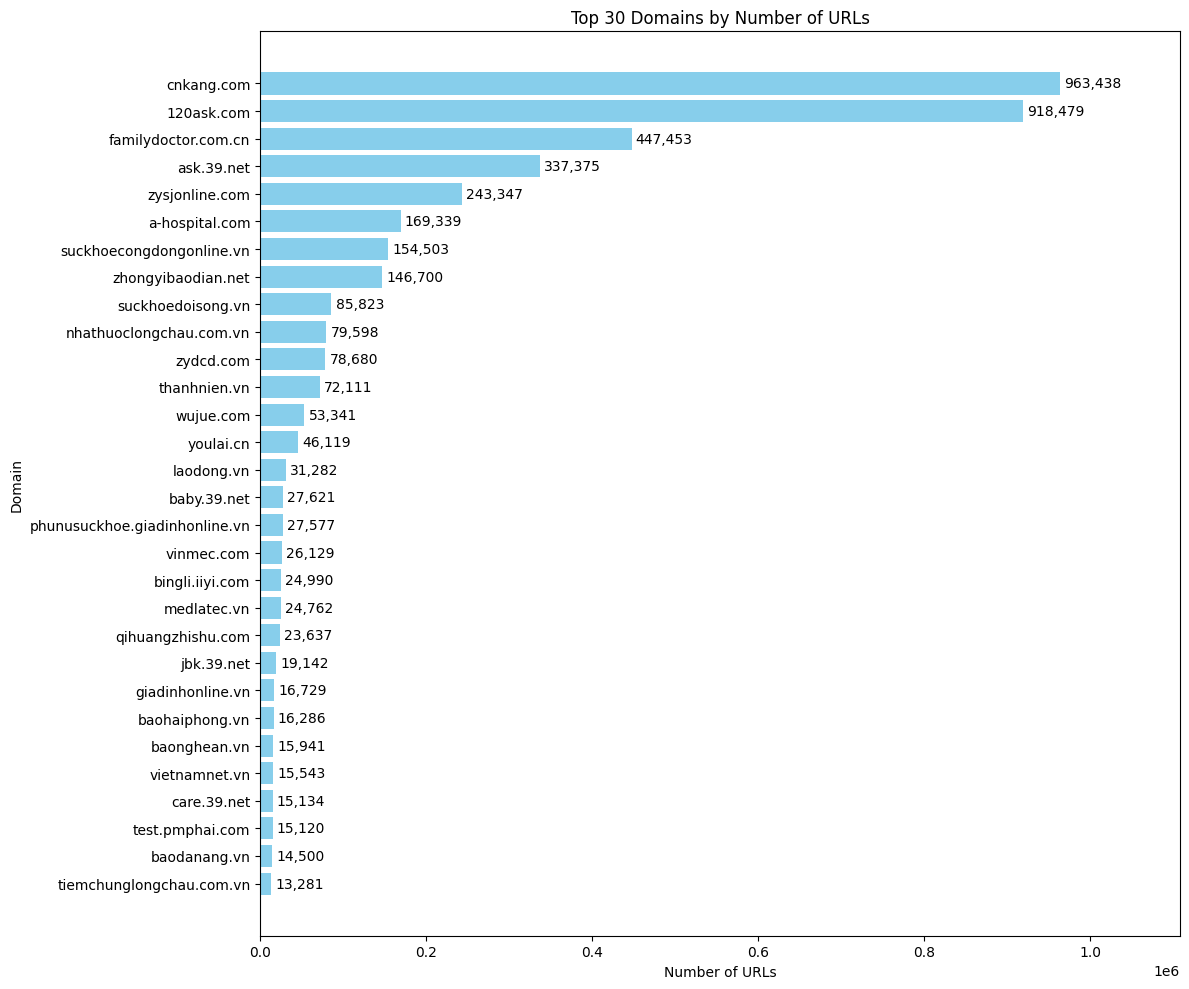

In [4]:
from urllib.parse import urlparse
from collections import Counter
import matplotlib.pyplot as plt

domain_counter = Counter()

for item in urls_full:
    # Nếu urls_full là list string:
    url = item

    # Nếu urls_full có dạng {"id": ..., "url": ...}
    # url = item["url"]

    try:
        domain = urlparse(url).netloc.lower()

        if domain.startswith("www."):
            domain = domain[4:]

        if domain:
            domain_counter[domain] += 1

    except Exception:
        pass


print(f"Total URLs: {sum(domain_counter.values()):,}")
print(f"Total unique domains: {len(domain_counter):,}")

# Top N domain
TOP_N = 30

top_domains = domain_counter.most_common(TOP_N)

domains = [x[0] for x in top_domains]
counts = [x[1] for x in top_domains]

# Đảo để domain lớn nhất nằm phía trên
domains = domains[::-1]
counts = counts[::-1]

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(domains, counts, color="skyblue")

# Hiển thị số lượng ở cuối mỗi thanh
ax.bar_label(bars, labels=[f"{count:,}" for count in counts], padding=3)

# Tạo thêm khoảng trống cho nhãn
ax.set_xlim(0, max(counts) * 1.15)

ax.set_xlabel("Number of URLs")
ax.set_ylabel("Domain")
ax.set_title(f"Top {TOP_N} Domains by Number of URLs")

plt.tight_layout()
plt.show()


# Domain profiling by URL pattern

Pipeline này profile từng domain và từng URL template bằng 30 URL được lấy mẫu phân tầng. Kết quả gồm selector, metadata, loại trang, pagination, mức phụ thuộc JavaScript và cờ nhiều template.

Quy trình full có checkpoint và **không tự chạy**. Cell smoke test phía dưới chỉ dùng `120ask.com` và `vinmec.com`.

In [ ]:
import asyncio
import hashlib
import json
import math
import random
import re
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import parse_qsl, unquote, urlsplit

import pandas as pd
import trafilatura
from bs4 import BeautifulSoup
from IPython.display import display
from playwright.async_api import (
    Browser,
    BrowserContext,
    Error as PlaywrightError,
    TimeoutError as PlaywrightTimeoutError,
    async_playwright,
)

OUTPUT_DIR = Path("domain_profiling_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_SAMPLE_SIZE = 30
DEFAULT_CONCURRENCY = 4
DEFAULT_RANDOM_SEED = 42
DEFAULT_PATTERN_COVERAGE = 0.95
DEFAULT_MAX_PATTERNS = 12
DEFAULT_TIMEOUT_MS = 25_000
DEFAULT_RENDER_WAIT_MS = 1_500

PAGE_QUERY_KEYS = {
    "page", "p", "paged", "pageno", "pageindex", "trang", "start", "offset"
}
UUID_RE = re.compile(
    r"^[0-9a-f]{8}-[0-9a-f]{4}-[1-5][0-9a-f]{3}-"
    r"[89ab][0-9a-f]{3}-[0-9a-f]{12}$",
    re.IGNORECASE,
)
ID_RE = re.compile(r"^(?:\d{4,}|[0-9a-f]{12,}|[a-z]*\d{5,}[a-z0-9_-]*)$", re.IGNORECASE)
FILE_RE = re.compile(r"^(.*?)(\.[a-z0-9]{1,6})$", re.IGNORECASE)


def normalize_domain(url: str) -> str:
    """Chuẩn hóa hostname để www.example.com và example.com cùng một domain."""
    try:
        hostname = (urlsplit(str(url).strip()).hostname or "").lower().rstrip(".")
    except (TypeError, ValueError):
        return ""
    return hostname.removeprefix("www.")


def _normalize_segment(segment: str, is_last: bool) -> str:
    """Chuẩn hóa một path segment, thay ID/UUID/slug động bằng wildcard `*`."""
    segment = unquote(segment).strip().lower()
    if not segment:
        return ""

    match = FILE_RE.match(segment)
    stem, extension = (match.group(1), match.group(2)) if match else (segment, "")

    if UUID_RE.match(stem) or ID_RE.match(stem):
        return f"*{extension}"

    looks_like_slug = (
        is_last
        and (
            len(stem) >= 24
            or stem.count("-") >= 2
            or stem.count("_") >= 2
            or bool(re.search(r"\d", stem))
        )
    )
    if looks_like_slug:
        return f"*{extension}"

    return segment


def infer_url_pattern(url: str) -> str:
    """Biến URL cụ thể thành path pattern ổn định, giữ lại query pagination."""
    try:
        parsed = urlsplit(str(url).strip())
    except (TypeError, ValueError):
        return "/"

    raw_segments = [segment for segment in parsed.path.split("/") if segment]
    normalized = [
        _normalize_segment(segment, index == len(raw_segments) - 1)
        for index, segment in enumerate(raw_segments)
    ]
    path = "/" + "/".join(segment for segment in normalized if segment)
    if parsed.path.endswith("/") and path != "/":
        path += "/"

    page_keys = sorted({
        key.lower()
        for key, _ in parse_qsl(parsed.query, keep_blank_values=True)
        if key.lower() in PAGE_QUERY_KEYS
    })
    if page_keys:
        path += "?" + "&".join(f"{key}=*" for key in page_keys)

    return path or "/"


assert infer_url_pattern(
    "https://www.120ask.com/question/19690714.htm"
) == "/question/*.htm"
assert infer_url_pattern(
    "https://www.vinmec.com/vie/bai-viet/dau-dau-keo-dai-la-benh-gi-vi"
) == "/vie/bai-viet/*"
assert infer_url_pattern(
    "https://example.com/benh/550e8400-e29b-41d4-a716-446655440000"
) == "/benh/*"
assert infer_url_pattern(
    "https://example.com/tin-tuc?page=2&utm_source=test"
) == "/tin-tuc?page=*"

print("URL pattern checks passed.")


URL pattern checks passed.


In [ ]:
def select_representative_patterns(
    counts: Counter,
    coverage_target: float = DEFAULT_PATTERN_COVERAGE,
    max_patterns: int = DEFAULT_MAX_PATTERNS,
) -> tuple[list[str], int]:
    """Chọn các pattern lớn nhất cho tới coverage mục tiêu hoặc giới hạn pattern."""
    if not counts:
        return [], 0

    total = sum(counts.values())
    selected = []
    covered = 0

    for pattern, count in counts.most_common(max_patterns):
        selected.append(pattern)
        covered += count
        if covered / total >= coverage_target:
            break

    return selected, total - covered


def build_pattern_inventory(
    urls,
    domains: set[str] | None = None,
    coverage_target: float = DEFAULT_PATTERN_COVERAGE,
    max_patterns: int = DEFAULT_MAX_PATTERNS,
) -> dict:
    """
    Pass 1: đếm domain và URL pattern.
    Chỉ giữ Counter, không materialize 4.4M URL trong RAM.
    """
    target_domains = {domain.lower().removeprefix("www.") for domain in domains} if domains else None
    domain_counts = Counter()
    pattern_counts = defaultdict(Counter)
    invalid_urls = 0

    for raw_url in urls:
        if not isinstance(raw_url, str) or not raw_url.strip():
            invalid_urls += 1
            continue

        domain = normalize_domain(raw_url)
        if not domain:
            invalid_urls += 1
            continue
        if target_domains is not None and domain not in target_domains:
            continue

        pattern = infer_url_pattern(raw_url)
        domain_counts[domain] += 1
        pattern_counts[domain][pattern] += 1

    selected_patterns = {}
    other_counts = {}
    for domain, counts in pattern_counts.items():
        selected, other_count = select_representative_patterns(
            counts,
            coverage_target=coverage_target,
            max_patterns=max_patterns,
        )
        selected_patterns[domain] = selected
        other_counts[domain] = other_count

    return {
        "domain_counts": domain_counts,
        "pattern_counts": dict(pattern_counts),
        "selected_patterns": selected_patterns,
        "other_counts": other_counts,
        "invalid_urls": invalid_urls,
        "coverage_target": coverage_target,
        "max_patterns": max_patterns,
    }


def allocate_pattern_quotas(
    counts: Counter,
    selected_patterns: list[str],
    sample_size: int,
) -> dict[str, int]:
    """Cấp ít nhất một sample/pattern rồi chia phần còn lại theo tần suất."""
    selected_patterns = [
        pattern for pattern in selected_patterns if counts.get(pattern, 0) > 0
    ]
    if not selected_patterns or sample_size <= 0:
        return {}

    if len(selected_patterns) > sample_size:
        selected_patterns = selected_patterns[:sample_size]

    quotas = {pattern: 1 for pattern in selected_patterns}
    remaining = sample_size - len(selected_patterns)
    total = sum(counts[pattern] for pattern in selected_patterns)

    if remaining > 0 and total > 0:
        raw_extra = {
            pattern: remaining * counts[pattern] / total
            for pattern in selected_patterns
        }
        for pattern in selected_patterns:
            extra = min(
                int(math.floor(raw_extra[pattern])),
                counts[pattern] - quotas[pattern],
            )
            quotas[pattern] += max(0, extra)

        remaining = sample_size - sum(quotas.values())
        order = sorted(
            selected_patterns,
            key=lambda pattern: (
                raw_extra[pattern] - math.floor(raw_extra[pattern]),
                counts[pattern],
                pattern,
            ),
            reverse=True,
        )

        while remaining > 0:
            changed = False
            for pattern in order:
                if quotas[pattern] < counts[pattern]:
                    quotas[pattern] += 1
                    remaining -= 1
                    changed = True
                    if remaining == 0:
                        break
            if not changed:
                break

    return quotas


def _stable_seed(random_seed: int, domain: str, pattern: str) -> int:
    """Tạo seed ổn định cho từng domain/pattern để sampling có thể tái lập."""
    digest = hashlib.sha256(
        f"{random_seed}|{domain}|{pattern}".encode("utf-8")
    ).hexdigest()
    return int(digest[:16], 16)


def stratified_reservoir_sample(
    urls,
    inventory: dict,
    sample_size: int = DEFAULT_SAMPLE_SIZE,
    random_seed: int = DEFAULT_RANDOM_SEED,
) -> list[dict]:
    """
    Pass 2: reservoir sampling có seed riêng cho từng domain/pattern.
    Bộ nhớ tối đa xấp xỉ số domain * sample_size.
    """
    quotas = {}
    selected_sets = {}
    for domain, selected in inventory["selected_patterns"].items():
        quotas[domain] = allocate_pattern_quotas(
            inventory["pattern_counts"][domain],
            selected,
            sample_size,
        )
        selected_sets[domain] = set(quotas[domain])

    reservoirs = defaultdict(list)
    seen = Counter()
    rngs = {
        (domain, pattern): random.Random(
            _stable_seed(random_seed, domain, pattern)
        )
        for domain, domain_quotas in quotas.items()
        for pattern in domain_quotas
    }

    for raw_url in urls:
        if not isinstance(raw_url, str):
            continue

        domain = normalize_domain(raw_url)
        if domain not in selected_sets:
            continue

        pattern = infer_url_pattern(raw_url)
        if pattern not in selected_sets[domain]:
            continue

        key = (domain, pattern)
        seen[key] += 1
        quota = quotas[domain][pattern]
        reservoir = reservoirs[key]

        if len(reservoir) < quota:
            reservoir.append(raw_url)
        else:
            replacement_index = rngs[key].randrange(seen[key])
            if replacement_index < quota:
                reservoir[replacement_index] = raw_url

    samples = []
    for (domain, pattern), sampled_urls in sorted(reservoirs.items()):
        for url in sampled_urls:
            samples.append({
                "domain": domain,
                "url_pattern": pattern,
                "url": url,
            })

    return samples


def prepare_domain_samples(
    urls,
    sample_size: int = DEFAULT_SAMPLE_SIZE,
    domains: list[str] | None = None,
    random_seed: int = DEFAULT_RANDOM_SEED,
    coverage_target: float = DEFAULT_PATTERN_COVERAGE,
    max_patterns: int = DEFAULT_MAX_PATTERNS,
) -> tuple[dict, list[dict]]:
    """Chạy hai pass inventory + reservoir sampling và trả metadata cùng URL mẫu."""
    inventory = build_pattern_inventory(
        urls,
        domains=set(domains) if domains else None,
        coverage_target=coverage_target,
        max_patterns=max_patterns,
    )
    samples = stratified_reservoir_sample(
        urls,
        inventory,
        sample_size=sample_size,
        random_seed=random_seed,
    )

    print(
        f"Prepared {len(samples):,} URLs across "
        f"{len(inventory['domain_counts']):,} domains."
    )
    return inventory, samples


In [ ]:
TITLE_SELECTORS = [
    '[itemprop="headline"]',
    "article h1",
    "main h1",
    ".article-title",
    ".post-title",
    ".entry-title",
    ".detail-title",
    ".news-title",
    "h1",
    'meta[property="og:title"]',
    "title",
]

CONTENT_SELECTORS = [
    '[itemprop="articleBody"]',
    "#article-content",
    "#content-detail",
    ".article-content",
    ".article-body",
    ".post-content",
    ".entry-content",
    ".detail-content",
    ".content-detail",
    ".news-content",
    ".main-content",
    "article",
    "main article",
    "main",
]

AUTHOR_SELECTORS = [
    '[itemprop="author"]',
    '[rel="author"]',
    ".article-author",
    ".post-author",
    ".author",
    'meta[name="author"]',
]

DATE_SELECTORS = [
    '[itemprop="datePublished"]',
    'time[datetime]',
    ".published-date",
    ".article-date",
    ".post-date",
    ".date",
    'meta[property="article:published_time"]',
    'meta[name="date"]',
]

PAGINATION_SELECTORS = [
    'a[rel="next"]',
    ".pagination",
    ".page-numbers",
    ".pager",
    '[class*="pagination"]',
    '[class*="paging"]',
]


def _clean_text(value: str | None) -> str:
    """Rút gọn whitespace để text DOM nhất quán trước khi đo và so sánh."""
    return re.sub(r"\s+", " ", value or "").strip()


def _element_value(element) -> str:
    """Lấy giá trị có ý nghĩa từ meta, time hoặc nội dung text của element."""
    if element.name == "meta":
        return _clean_text(element.get("content"))
    if element.name == "time" and element.get("datetime"):
        return _clean_text(element.get("datetime"))
    return _clean_text(element.get_text(" ", strip=True))


def _candidate_score(element, purpose: str) -> tuple[float, int, int, float]:
    """Chấm điểm element theo mục đích title/content/metadata và trả các DOM metrics."""
    text = _element_value(element)
    text_length = len(text)
    paragraph_count = len(element.select("p")) if hasattr(element, "select") else 0
    link_text_length = sum(
        len(_clean_text(link.get_text(" ", strip=True)))
        for link in element.select("a")
    ) if hasattr(element, "select") else 0
    link_density = link_text_length / max(text_length, 1)

    if purpose == "title":
        score = 0.0
        if 8 <= text_length <= 300:
            score += 4.0
        if element.name == "h1":
            score += 3.0
        if element.name == "meta":
            score += 2.0
        score -= max(0, text_length - 300) / 100
    elif purpose == "content":
        if text_length < 120:
            return -1.0, text_length, paragraph_count, link_density
        score = min(text_length / 500, 12)
        score += min(paragraph_count, 25) * 0.35
        score -= min(link_density, 1.0) * 8
        if element.name == "article" or element.get("itemprop") == "articleBody":
            score += 3.0
        if element.name in {"main", "body"}:
            score -= 1.0
    else:
        score = 2.0 if text_length else -1.0

    return score, text_length, paragraph_count, round(link_density, 4)


def select_best_candidate(
    soup: BeautifulSoup,
    selectors: list[str],
    purpose: str,
) -> dict | None:
    """Thử danh sách CSS selector và chọn element có điểm nội dung tốt nhất."""
    best = None

    for selector_index, selector in enumerate(selectors):
        try:
            elements = soup.select(selector)
        except Exception:
            continue

        for element in elements:
            value = _element_value(element)
            if not value:
                continue

            score, text_length, paragraph_count, link_density = _candidate_score(
                element,
                purpose,
            )
            if score < 0:
                continue

            candidate = {
                "selector": selector,
                "value": value[:500] if purpose != "content" else None,
                "text_length": text_length,
                "paragraph_count": paragraph_count,
                "link_density": link_density,
                "score": round(score - selector_index * 0.01, 4),
                "_text": value,
            }
            if best is None or candidate["score"] > best["score"]:
                best = candidate

    return best


def _iter_jsonld_nodes(value):
    """Duyệt đệ quy toàn bộ object/list trong payload JSON-LD."""
    if isinstance(value, dict):
        yield value
        for child in value.values():
            yield from _iter_jsonld_nodes(child)
    elif isinstance(value, list):
        for child in value:
            yield from _iter_jsonld_nodes(child)


def extract_jsonld_metadata(soup: BeautifulSoup) -> dict:
    """Thu thập schema types, author và ngày xuất bản từ các block JSON-LD."""
    types = set()
    authors = []
    dates = []

    for script in soup.select('script[type="application/ld+json"]'):
        raw = script.string or script.get_text()
        if not raw.strip():
            continue
        try:
            payload = json.loads(raw)
        except (json.JSONDecodeError, TypeError):
            continue

        for node in _iter_jsonld_nodes(payload):
            node_type = node.get("@type")
            if isinstance(node_type, str):
                types.add(node_type.lower())
            elif isinstance(node_type, list):
                types.update(str(item).lower() for item in node_type)

            author = node.get("author")
            if isinstance(author, dict):
                author = author.get("name")
            elif isinstance(author, list):
                author = ", ".join(
                    str(item.get("name") if isinstance(item, dict) else item)
                    for item in author
                )
            if author:
                authors.append(_clean_text(str(author)))

            date_value = node.get("datePublished") or node.get("dateCreated")
            if date_value:
                dates.append(_clean_text(str(date_value)))

    return {
        "types": sorted(types),
        "author": next((value for value in authors if value), None),
        "date": next((value for value in dates if value), None),
    }


def detect_pagination(soup: BeautifulSoup, url: str) -> dict:
    """Phát hiện phân trang từ rel=next, container pagination và URL page/query."""
    evidence = []
    for selector in PAGINATION_SELECTORS:
        try:
            if soup.select_one(selector):
                evidence.append(f"selector:{selector}")
        except Exception:
            continue

    for link in soup.select("a[href]"):
        href = link.get("href", "")
        try:
            query_keys = {
                key.lower()
                for key, _ in parse_qsl(urlsplit(href).query)
            }
        except ValueError:
            continue
        if query_keys & PAGE_QUERY_KEYS:
            evidence.append("pagination-query-link")
            break
        if re.search(r"/(?:page|trang)/?\d+", href, re.IGNORECASE):
            evidence.append("pagination-path-link")
            break

    current_query_keys = {
        key.lower()
        for key, _ in parse_qsl(urlsplit(url).query)
    }
    if current_query_keys & PAGE_QUERY_KEYS:
        evidence.append("current-url-pagination-query")

    evidence = list(dict.fromkeys(evidence))
    return {
        "value": bool(evidence),
        "confidence": round(min(0.98, 0.55 + 0.15 * len(evidence)), 2)
        if evidence else 0.85,
        "evidence": evidence,
    }


def classify_page(
    url: str,
    url_pattern: str,
    jsonld_types: list[str],
    title: str,
    content_text: str,
) -> dict:
    """Phân loại loại trang bằng URL, schema.org và tín hiệu text; kèm confidence."""
    scores = defaultdict(float)
    evidence = defaultdict(list)
    path = urlsplit(url).path.lower()
    combined = f"{title} {content_text[:2500]}".lower()
    schema_types = set(jsonld_types)

    def add(label: str, score: float, reason: str):
        """Cộng trọng số và lưu bằng chứng cho một nhãn ứng viên."""
        scores[label] += score
        evidence[label].append(reason)

    if schema_types & {"qapage", "question", "answer"}:
        add("medical_qa", 0.80, "schema.org QAPage/Question/Answer")
    if any(token in path for token in (
        "/question/", "/ask/", "hoi-dap", "hoidap", "tu-van", "consult"
    )):
        add("medical_qa", 0.48, "URL contains Q&A keyword")
    if any(token in combined for token in (
        "câu hỏi:", "trả lời:", "bác sĩ trả lời", "最佳答案", "医生回答"
    )):
        add("medical_qa", 0.28, "page text contains Q&A markers")

    if schema_types & {"newsarticle", "reportagenewsarticle"}:
        add("news", 0.82, "schema.org NewsArticle")
    if any(token in path for token in (
        "/tin-tuc/", "/news/", "/thoi-su/", "/bao-"
    )):
        add("news", 0.52, "URL contains news keyword")

    if schema_types & {"medicalwebpage", "medicalcondition"}:
        add("disease_page", 0.72, "schema.org medical page")
    if any(token in path for token in (
        "/benh/", "/disease/", "/bingli/", "/jbk/"
    )):
        add("disease_page", 0.58, "URL contains disease keyword")

    if schema_types & {"article", "blogposting", "webpage"}:
        add("medical_article", 0.68, "schema.org Article/WebPage")
    if any(token in path for token in ("/bai-viet/", "/zhishi/")):
        add("medical_article", 0.88, "URL matches a strong medical-article pattern")
    elif any(token in path for token in (
        "/article/", "/knowledge/", "/blog/"
    )):
        add("medical_article", 0.52, "URL contains article keyword")
    if len(content_text) >= 800:
        add("medical_article", 0.22, "substantial article-like content")

    if not scores:
        return {
            "page_type": "other",
            "confidence": 0.25,
            "evidence": ["No strong schema, URL, or DOM signal"],
            "needs_review": True,
        }

    page_type, raw_score = max(
        scores.items(),
        key=lambda item: (item[1], item[0]),
    )
    confidence = round(min(0.99, raw_score), 2)
    if confidence < 0.45:
        page_type = "other"

    return {
        "page_type": page_type,
        "confidence": confidence,
        "evidence": evidence[page_type],
        "needs_review": confidence < 0.60,
    }


def html_metrics(html: str) -> dict:
    """Đo text, số node và độ dài main content để so sánh trước/sau render."""
    if not html:
        return {"text_length": 0, "node_count": 0, "content_length": 0}

    soup = BeautifulSoup(html, "lxml")
    text_length = len(_clean_text(soup.get_text(" ", strip=True)))
    node_count = len(soup.find_all(True))
    content = select_best_candidate(soup, CONTENT_SELECTORS, "content")

    return {
        "text_length": text_length,
        "node_count": node_count,
        "content_length": content["text_length"] if content else 0,
        "content_selector": content["selector"] if content else None,
    }


def detect_js_rendering(raw_html: str, rendered_html: str) -> dict:
    """Xác định trang phụ thuộc JavaScript bằng mức tăng DOM và nội dung sau render."""
    if not raw_html:
        return {
            "value": None,
            "confidence": 0.0,
            "evidence": ["Initial response HTML unavailable"],
        }

    raw = html_metrics(raw_html)
    rendered = html_metrics(rendered_html)
    evidence = []

    text_delta = rendered["text_length"] - raw["text_length"]
    node_delta = rendered["node_count"] - raw["node_count"]
    content_delta = rendered["content_length"] - raw["content_length"]

    if raw["text_length"] < 400 and rendered["text_length"] > 1_000:
        evidence.append("rendered text appears after JavaScript")
    if content_delta > 500 and rendered["content_length"] > max(
        1_000, raw["content_length"] * 1.5
    ):
        evidence.append("main content grows substantially after render")
    if node_delta > 200 and rendered["node_count"] > max(
        500, raw["node_count"] * 1.5
    ):
        evidence.append("DOM node count grows substantially after render")
    if (
        not raw["content_selector"]
        and rendered["content_selector"]
        and rendered["content_length"] > 300
    ):
        evidence.append("content selector exists only after render")

    return {
        "value": bool(evidence),
        "confidence": round(min(0.98, 0.62 + 0.10 * len(evidence)), 2)
        if evidence else 0.78,
        "evidence": evidence or ["No material DOM/content growth after render"],
        "metrics": {"initial": raw, "rendered": rendered},
    }


def analyze_rendered_page(
    url: str,
    url_pattern: str,
    raw_html: str,
    rendered_html: str,
) -> dict:
    """Phân tích một trang đã render và gom selector, metadata, type, pagination, JS signal."""
    soup = BeautifulSoup(rendered_html or "", "lxml")
    title_info = select_best_candidate(soup, TITLE_SELECTORS, "title")
    content_info = select_best_candidate(soup, CONTENT_SELECTORS, "content")
    author_info = select_best_candidate(soup, AUTHOR_SELECTORS, "metadata")
    date_info = select_best_candidate(soup, DATE_SELECTORS, "metadata")
    jsonld = extract_jsonld_metadata(soup)

    extracted_text = ""
    if content_info:
        extracted_text = content_info.pop("_text", "")
    else:
        extracted_text = trafilatura.extract(
            rendered_html,
            url=url,
            include_comments=False,
            include_tables=True,
            favor_precision=True,
        ) or ""
        if extracted_text:
            content_info = {
                "selector": None,
                "value": None,
                "text_length": len(extracted_text),
                "paragraph_count": extracted_text.count("\n"),
                "link_density": None,
                "score": None,
                "extraction_method": "trafilatura-fallback",
            }

    title = title_info.pop("_text", "") if title_info else ""
    if author_info:
        author_info.pop("_text", None)
    elif jsonld["author"]:
        author_info = {
            "selector": 'script[type="application/ld+json"]::author',
            "value": jsonld["author"],
        }
    if date_info:
        date_info.pop("_text", None)
    elif jsonld["date"]:
        date_info = {
            "selector": 'script[type="application/ld+json"]::datePublished',
            "value": jsonld["date"],
        }

    classification = classify_page(
        url,
        url_pattern,
        jsonld["types"],
        title,
        extracted_text,
    )
    pagination = detect_pagination(soup, url)
    js_render = detect_js_rendering(raw_html, rendered_html)

    return {
        "title": title_info,
        "content": content_info,
        "author": author_info,
        "date": date_info,
        "jsonld_types": jsonld["types"],
        "classification": classification,
        "pagination": pagination,
        "js_render": js_render,
        "content_preview": _clean_text(extracted_text)[:500],
        "dom_fingerprint": "|".join([
            classification["page_type"],
            (title_info or {}).get("selector") or "no-title-selector",
            (content_info or {}).get("selector") or "no-content-selector",
        ]),
    }


In [ ]:
PROFILE_VERSION = "1.0"


def load_checkpoint(path: Path) -> dict[str, dict]:
    """Đọc checkpoint JSONL và trả các kết quả đúng profile version theo URL."""
    cached = {}
    if not path.exists():
        return cached

    with path.open("r", encoding="utf-8") as checkpoint_file:
        for line_number, line in enumerate(checkpoint_file, start=1):
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                print(f"Skipping invalid checkpoint line {line_number}.")
                continue
            if record.get("profile_version") == PROFILE_VERSION and record.get("url"):
                cached[record["url"]] = record

    return cached


def append_checkpoint(path: Path, record: dict) -> None:
    """Ghi ngay một kết quả crawl vào JSONL để có thể resume khi bị ngắt."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as checkpoint_file:
        checkpoint_file.write(
            json.dumps(record, ensure_ascii=False) + "\n"
        )


async def _route_handler(route) -> None:
    """Chặn image/media/font để crawler tải trang nhanh và tốn ít băng thông hơn."""
    if route.request.resource_type in {"image", "media", "font"}:
        await route.abort()
    else:
        await route.continue_()


async def inspect_url(
    context: BrowserContext,
    sample: dict,
    global_semaphore: asyncio.Semaphore,
    domain_lock: asyncio.Lock,
    timeout_ms: int = DEFAULT_TIMEOUT_MS,
    render_wait_ms: int = DEFAULT_RENDER_WAIT_MS,
    retries: int = 2,
) -> dict:
    """Mở một URL, lấy HTML gốc + DOM render, phân tích và chuẩn hóa lỗi thành record."""
    base = {
        "profile_version": PROFILE_VERSION,
        "url": sample["url"],
        "domain": sample["domain"],
        "url_pattern": sample["url_pattern"],
        "success": False,
        "status": None,
        "final_url": None,
        "error_type": None,
        "error": None,
    }

    async with global_semaphore, domain_lock:
        for attempt in range(retries + 1):
            page = await context.new_page()
            try:
                response = await page.goto(
                    sample["url"],
                    wait_until="domcontentloaded",
                    timeout=timeout_ms,
                )
                status = response.status if response else None
                base["status"] = status
                base["final_url"] = page.url

                if status in {401, 403, 429}:
                    base["error_type"] = "blocked_or_rate_limited"
                    base["error"] = f"HTTP {status}; no bypass attempted"
                    return base
                if status and status >= 400 and status < 500:
                    base["error_type"] = "http_client_error"
                    base["error"] = f"HTTP {status}"
                    return base
                if status and status >= 500:
                    raise RuntimeError(f"HTTP {status}")

                raw_html = ""
                if response:
                    try:
                        raw_html = await response.text()
                    except PlaywrightError:
                        raw_html = ""

                try:
                    await page.wait_for_selector(
                        "body",
                        state="attached",
                        timeout=min(timeout_ms, 10_000),
                    )
                except PlaywrightTimeoutError:
                    pass

                await page.wait_for_timeout(render_wait_ms)
                rendered_html = await page.content()

                try:
                    visible_text = _clean_text(
                        await page.locator("body").inner_text(timeout=5_000)
                    )[:5_000].lower()
                except PlaywrightError:
                    visible_text = ""
                page_title = (await page.title()).lower()
                blocked_markers = (
                    "captcha",
                    "verify you are human",
                    "access denied",
                    "robot check",
                    "人机验证",
                )
                if any(marker in f"{page_title} {visible_text}" for marker in blocked_markers):
                    base["error_type"] = "bot_protection"
                    base["error"] = "Bot-protection page detected; no bypass attempted"
                    return base

                analysis = analyze_rendered_page(
                    page.url,
                    sample["url_pattern"],
                    raw_html,
                    rendered_html,
                )
                return {
                    **base,
                    "success": True,
                    "error_type": None,
                    "error": None,
                    "analysis": analysis,
                }

            except PlaywrightTimeoutError as error:
                base["error_type"] = "timeout"
                base["error"] = str(error)
            except (PlaywrightError, RuntimeError, ValueError) as error:
                base["error_type"] = type(error).__name__
                base["error"] = str(error)
            except Exception as error:
                base["error_type"] = type(error).__name__
                base["error"] = str(error)
            finally:
                await page.close()

            if attempt < retries:
                await asyncio.sleep(2 ** attempt)

    return base


async def crawl_samples(
    samples: list[dict],
    checkpoint_path: Path,
    concurrency: int = DEFAULT_CONCURRENCY,
    timeout_ms: int = DEFAULT_TIMEOUT_MS,
    render_wait_ms: int = DEFAULT_RENDER_WAIT_MS,
    retries: int = 2,
) -> list[dict]:
    """Crawl batch có concurrency, khóa theo domain và tái sử dụng checkpoint đã có."""
    cached = load_checkpoint(checkpoint_path)
    pending = [sample for sample in samples if sample["url"] not in cached]
    results = [cached[sample["url"]] for sample in samples if sample["url"] in cached]

    print(
        f"Checkpoint: {len(results):,} cached; "
        f"{len(pending):,} pending."
    )
    if not pending:
        return results

    semaphore = asyncio.Semaphore(max(1, concurrency))
    domain_locks = defaultdict(asyncio.Lock)

    async with async_playwright() as playwright:
        browser: Browser = await playwright.chromium.launch(headless=True)
        context = await browser.new_context(
            locale="vi-VN",
            user_agent=(
                "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0 Safari/537.36"
            ),
            extra_http_headers={"Accept-Language": "vi-VN,vi;q=0.9,en;q=0.7"},
        )
        await context.route("**/*", _route_handler)

        tasks = [
            asyncio.create_task(
                inspect_url(
                    context,
                    sample,
                    semaphore,
                    domain_locks[sample["domain"]],
                    timeout_ms=timeout_ms,
                    render_wait_ms=render_wait_ms,
                    retries=retries,
                )
            )
            for sample in pending
        ]

        try:
            for completed_index, task in enumerate(
                asyncio.as_completed(tasks),
                start=1,
            ):
                record = await task
                results.append(record)
                append_checkpoint(checkpoint_path, record)

                if completed_index % 10 == 0 or completed_index == len(tasks):
                    successes = sum(item.get("success", False) for item in results)
                    print(
                        f"Completed {completed_index:,}/{len(tasks):,} pending; "
                        f"{successes:,}/{len(results):,} successful."
                    )
        finally:
            for task in tasks:
                if not task.done():
                    task.cancel()
            await context.close()
            await browser.close()

    return results


In [ ]:
def _mode_with_coverage(
    records: list[dict],
    field: str,
    denominator: int,
) -> dict:
    """Chọn selector xuất hiện nhiều nhất và tính coverage trên các sample thành công."""
    values = []
    examples = []

    for record in records:
        info = record.get("analysis", {}).get(field)
        if not info:
            continue
        selector = info.get("selector")
        if selector:
            values.append(selector)
        if info.get("value"):
            examples.append(info["value"])

    if not values:
        return {
            "selector": None,
            "coverage": 0.0,
            "example": examples[0] if examples else None,
        }

    selector, count = Counter(values).most_common(1)[0]
    return {
        "selector": selector,
        "coverage": round(count / max(denominator, 1), 3),
        "example": next(iter(examples), None),
    }


def _aggregate_boolean_signal(
    records: list[dict],
    field: str,
    true_threshold: float,
) -> dict:
    """Gộp tín hiệu boolean nhiều trang thành value, ratio, confidence và evidence."""
    values = []
    confidences = []
    evidence = []

    for record in records:
        info = record.get("analysis", {}).get(field, {})
        value = info.get("value")
        if value is None:
            continue
        values.append(bool(value))
        confidences.append(float(info.get("confidence", 0)))
        evidence.extend(info.get("evidence", []))

    if not values:
        return {
            "value": None,
            "ratio": None,
            "confidence": 0.0,
            "evidence": [],
        }

    ratio = sum(values) / len(values)
    aggregate_value = ratio >= true_threshold
    return {
        "value": aggregate_value,
        "ratio": round(ratio, 3),
        "confidence": round(
            sum(confidences) / len(confidences),
            3,
        ) if confidences else 0.0,
        "evidence": list(dict.fromkeys(evidence))[:8],
    }


def aggregate_profiles(
    inventory: dict,
    records: list[dict],
    sample_size: int,
    random_seed: int,
    requested_domains: list[str] | None,
    total_input_urls: int,
) -> dict:
    """Tổng hợp record theo domain/pattern thành schema JSON cuối cùng và cờ review."""
    grouped = defaultdict(lambda: defaultdict(list))
    for record in records:
        grouped[record["domain"]][record["url_pattern"]].append(record)

    domain_profiles = []

    for domain in sorted(
        inventory["domain_counts"],
        key=inventory["domain_counts"].get,
        reverse=True,
    ):
        domain_records = [
            record
            for pattern_records in grouped.get(domain, {}).values()
            for record in pattern_records
        ]
        successful_domain_records = [
            record for record in domain_records if record.get("success")
        ]
        error_counts = Counter(
            record.get("error_type") or "unknown"
            for record in domain_records
            if not record.get("success")
        )
        templates = []
        significant_fingerprints = set()

        for pattern in inventory["selected_patterns"].get(domain, []):
            pattern_records = grouped.get(domain, {}).get(pattern, [])
            successful = [
                record for record in pattern_records if record.get("success")
            ]
            classifications = [
                record["analysis"]["classification"]
                for record in successful
            ]
            type_counts = Counter(
                item["page_type"] for item in classifications
            )

            if type_counts:
                page_type = type_counts.most_common(1)[0][0]
                matching = [
                    item for item in classifications
                    if item["page_type"] == page_type
                ]
                classification_confidence = round(
                    sum(item["confidence"] for item in matching) / len(matching),
                    3,
                )
                classification_evidence = list(dict.fromkeys(
                    evidence
                    for item in matching
                    for evidence in item.get("evidence", [])
                ))
            else:
                page_type = "other"
                classification_confidence = 0.0
                classification_evidence = ["No successfully fetched sample"]

            fingerprints = Counter(
                record["analysis"].get("dom_fingerprint")
                for record in successful
                if record["analysis"].get("dom_fingerprint")
            )
            stable_fingerprints = [
                fingerprint
                for fingerprint, count in fingerprints.items()
                if count >= 2
            ]
            significant_fingerprints.update(stable_fingerprints)

            title_selector = _mode_with_coverage(
                successful,
                "title",
                len(successful),
            )
            content_selector = _mode_with_coverage(
                successful,
                "content",
                len(successful),
            )
            author = _mode_with_coverage(
                successful,
                "author",
                len(successful),
            )
            date = _mode_with_coverage(
                successful,
                "date",
                len(successful),
            )
            pagination = _aggregate_boolean_signal(
                successful,
                "pagination",
                true_threshold=0.20,
            )
            js_render = _aggregate_boolean_signal(
                successful,
                "js_render",
                true_threshold=0.30,
            )

            fetch_success_rate = round(
                len(successful) / max(len(pattern_records), 1),
                3,
            )
            needs_review = (
                classification_confidence < 0.60
                or fetch_success_rate < 0.50
                or content_selector["coverage"] < 0.50
            )

            templates.append({
                "url_pattern": pattern,
                "url_count": inventory["pattern_counts"][domain][pattern],
                "domain_coverage": round(
                    inventory["pattern_counts"][domain][pattern]
                    / inventory["domain_counts"][domain],
                    4,
                ),
                "sample_count": len(pattern_records),
                "successful_samples": len(successful),
                "fetch_success_rate": fetch_success_rate,
                "page_type": page_type,
                "classification_confidence": classification_confidence,
                "classification_evidence": classification_evidence,
                "needs_review": needs_review,
                "title_selector": title_selector,
                "content_selector": content_selector,
                "author": author,
                "date": date,
                "has_pagination": pagination["value"],
                "pagination": pagination,
                "js_rendered": js_render["value"],
                "js_render": js_render,
                "template_fingerprints": dict(fingerprints),
                "sample_urls": [
                    record["url"] for record in pattern_records[:5]
                ],
            })

        # Khác pattern + khác signature cũng được tính là nhiều template.
        pattern_signatures = {
            (
                template["page_type"],
                template["title_selector"]["selector"],
                template["content_selector"]["selector"],
            )
            for template in templates
            if template["successful_samples"] >= 2
        }
        has_multiple_templates = (
            len(significant_fingerprints) >= 2
            or len(pattern_signatures) >= 2
        )

        domain_profiles.append({
            "domain": domain,
            "total_urls": inventory["domain_counts"][domain],
            "sampled_urls": len(domain_records),
            "successful_samples": len(successful_domain_records),
            "fetch_success_rate": round(
                len(successful_domain_records) / max(len(domain_records), 1),
                3,
            ),
            "has_multiple_templates": has_multiple_templates,
            "template_count": len(templates),
            "profiled_url_count": sum(
                template["url_count"] for template in templates
            ),
            "unprofiled_url_count": inventory["other_counts"].get(domain, 0),
            "templates": templates,
            "errors": dict(error_counts),
        })

    return {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "profile_version": PROFILE_VERSION,
        "config": {
            "sample_size_per_domain": sample_size,
            "random_seed": random_seed,
            "pattern_coverage_target": inventory["coverage_target"],
            "max_patterns_per_domain": inventory["max_patterns"],
            "requested_domains": requested_domains or "all",
        },
        "dataset_summary": {
            "total_input_urls": total_input_urls,
            "profiled_domain_count": len(domain_profiles),
            "invalid_url_count": inventory["invalid_urls"],
            "sampled_url_count": len(records),
            "successful_url_count": sum(
                record.get("success", False) for record in records
            ),
        },
        "domains": domain_profiles,
    }


def profiles_to_dataframe(profiles: dict) -> pd.DataFrame:
    """Flatten JSON domain/template thành DataFrame gọn để kiểm tra trong notebook."""
    rows = []
    for domain in profiles.get("domains", []):
        for template in domain.get("templates", []):
            rows.append({
                "domain": domain["domain"],
                "domain_urls": domain["total_urls"],
                "multiple_templates": domain["has_multiple_templates"],
                "url_pattern": template["url_pattern"],
                "pattern_urls": template["url_count"],
                "page_type": template["page_type"],
                "confidence": template["classification_confidence"],
                "title_selector": template["title_selector"]["selector"],
                "content_selector": template["content_selector"]["selector"],
                "author_selector": template["author"]["selector"],
                "date_selector": template["date"]["selector"],
                "pagination": template["has_pagination"],
                "js_rendered": template["js_rendered"],
                "success_rate": template["fetch_success_rate"],
                "needs_review": template["needs_review"],
            })

    return pd.DataFrame(rows)


async def profile_domains(
    urls,
    sample_size: int = DEFAULT_SAMPLE_SIZE,
    domains: list[str] | None = None,
    concurrency: int = DEFAULT_CONCURRENCY,
    random_seed: int = DEFAULT_RANDOM_SEED,
    coverage_target: float = DEFAULT_PATTERN_COVERAGE,
    max_patterns: int = DEFAULT_MAX_PATTERNS,
    timeout_ms: int = DEFAULT_TIMEOUT_MS,
    render_wait_ms: int = DEFAULT_RENDER_WAIT_MS,
    retries: int = 2,
    output_dir: Path | str = OUTPUT_DIR,
    output_name: str = "domain_profiles.json",
    checkpoint_name: str = "domain_profile_samples.jsonl",
) -> dict:
    """Điều phối toàn pipeline: inventory, sample, crawl, aggregate và ghi JSON output."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    inventory, samples = prepare_domain_samples(
        urls,
        sample_size=sample_size,
        domains=domains,
        random_seed=random_seed,
        coverage_target=coverage_target,
        max_patterns=max_patterns,
    )
    records = await crawl_samples(
        samples,
        checkpoint_path=output_dir / checkpoint_name,
        concurrency=concurrency,
        timeout_ms=timeout_ms,
        render_wait_ms=render_wait_ms,
        retries=retries,
    )
    profiles = aggregate_profiles(
        inventory,
        records,
        sample_size=sample_size,
        random_seed=random_seed,
        requested_domains=domains,
        total_input_urls=len(urls),
    )

    output_path = output_dir / output_name
    with output_path.open("w", encoding="utf-8") as output_file:
        json.dump(
            profiles,
            output_file,
            ensure_ascii=False,
            indent=2,
        )

    print(f"Saved domain profiles to: {output_path.resolve()}")
    return profiles


## Smoke test và full run

Smoke test lấy tối đa 6 URL/domain trên hai domain mẫu và giới hạn 2 pattern/domain. Lỗi mạng, HTTP 403/429 hoặc bot protection sẽ được ghi vào JSON thay vì làm dừng notebook.

Cell full run bên dưới mặc định tắt. Đổi `RUN_FULL_PROFILE = True` khi muốn profile toàn bộ 97 domain.

In [ ]:
SMOKE_TEST_DOMAINS = ["120ask.com", "vinmec.com"]

smoke_profiles = await profile_domains(
    urls_full,
    sample_size=6,
    domains=SMOKE_TEST_DOMAINS,
    concurrency=2,
    random_seed=42,
    max_patterns=2,
    timeout_ms=20_000,
    retries=0,
    output_name="smoke_domain_profiles.json",
    checkpoint_name="smoke_domain_profile_samples.jsonl",
)

assert set(
    profile["domain"] for profile in smoke_profiles["domains"]
).issubset(set(SMOKE_TEST_DOMAINS))
assert all(
    "templates" in profile
    and "has_multiple_templates" in profile
    and "errors" in profile
    for profile in smoke_profiles["domains"]
)
json.dumps(smoke_profiles, ensure_ascii=False)

smoke_df = profiles_to_dataframe(smoke_profiles)
display(smoke_df)
print("Smoke test completed and output is JSON-serializable.")


Prepared 12 URLs across 2 domains.
Checkpoint: 0 cached; 12 pending.
Completed 10/12 pending; 7/10 successful.
Completed 12/12 pending; 9/12 successful.
Saved domain profiles to: /Volumes/security/lucraft@lucraftmeds/lucraftmeds@notebooks/dataset-creation/domain_profiling_output/smoke_domain_profiles.json


,domain,domain_urls,multiple_templates,url_pattern,pattern_urls,page_type,confidence,title_selector,content_selector,author_selector,date_selector,pagination,js_rendered,success_rate,needs_review
0,120ask.com,918479,False,/question/*.htm,918479,medical_qa,0.48,h1,None,None,None,False,False,0.5,True
1,vinmec.com,26129,False,/vie/bai-viet/*,26127,medical_article,0.99,main h1,.detail-content,"script[type=""application/ld+json""]::author","script[type=""application/ld+json""]::datePublished",False,False,1.0,False


Smoke test completed and output is JSON-serializable.


In [12]:
RUN_FULL_PROFILE = True

if RUN_FULL_PROFILE:
    profiles = await profile_domains(
        urls_full,
        sample_size=30,
        domains=None,
        concurrency=4,
        random_seed=42,
        output_name="domain_profiles.json",
        checkpoint_name="domain_profile_samples.jsonl",
    )
    domain_profiles_df = profiles_to_dataframe(profiles)
    display(
        domain_profiles_df.sort_values(
            ["domain_urls", "pattern_urls"],
            ascending=[False, False],
        )
    )
else:
    print(
        "Full profiling is disabled. "
        "Set RUN_FULL_PROFILE = True to profile all domains."
    )


Prepared 2,720 URLs across 97 domains.
Checkpoint: 0 cached; 2,720 pending.
Completed 10/2,720 pending; 9/10 successful.
Completed 20/2,720 pending; 19/20 successful.
Completed 30/2,720 pending; 24/30 successful.
Completed 40/2,720 pending; 34/40 successful.
Completed 50/2,720 pending; 44/50 successful.
Completed 60/2,720 pending; 53/60 successful.


TargetClosedError: BrowserContext.close: Target page, context or browser has been closed